# Single Student Mental Model + Context-Enriched Prompt

This notebook builds a mental model for one student and evaluates assessment quality using a single context-enriched prompt that combines:
1) syllabus/curriculum context
2) student mental-model context

In [16]:
# 1) Configuration and Imports
from pathlib import Path
import sys
import importlib
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import lib.experiment_utils as experiment_utils
import lib.mental_model as mental_model

importlib.reload(experiment_utils)
importlib.reload(mental_model)

from lib.experiment_utils import (
    create_client,
    load_best_attempts_df,
    select_target_student_id,
    get_student_data,
    save_results,
)
from lib.mental_model import (
    load_skill_map,
    calculate_student_profile,
    build_prerequisite_graph,
    get_weak_skills,
    build_mental_model_payload,
    build_context_enriched_prompt,
    run_context_enriched_eval,
    summarize_context_eval,
)

MODEL_ID = "gemini-2.5-flash"
RANDOM_SEED = 42
MIN_SUBMISSIONS = 8
if "TARGET_STUDENT_ID" not in globals():
    TARGET_STUDENT_ID = None

client = create_client()
print(f"Environment ready. Using model: {MODEL_ID}")

Environment ready. Using model: gemini-2.5-flash


In [17]:
# 2) Load Data and Select One Student
best_attempts_df = load_best_attempts_df()
TARGET_STUDENT_ID = select_target_student_id(
    best_attempts_df=best_attempts_df,
    target_student_id=TARGET_STUDENT_ID,
    min_submissions=MIN_SUBMISSIONS,
)
student_data = get_student_data(best_attempts_df, TARGET_STUDENT_ID)

student_scores = best_attempts_df.groupby("SubjectID")["Score"].mean()
print(f"Selected student: {TARGET_STUDENT_ID}")
print(f"Student average score: {student_scores.loc[TARGET_STUDENT_ID]:.3f}")
print(f"Submissions available: {len(student_data)}")
display(student_data.head())

Main table: 201,570 rows
CodeState table: 69,627 rows
Subject table: 381 rows
Joined dataset: 191,584 rows
Best attempts: 15,375 rows (372 students, 50 problems)
Selected student: 14374
Student average score: 0.540
Submissions available: 33


,SubjectID,ProblemID,Order,ToolInstances,ServerTimestamp,ServerTimezone,CourseID,CourseSectionID,TermID,AssignmentID,...,EventType,Score,Compile.Result,CompileMessageType,CompileMessageData,EventID,ParentEventID,SourceLocation,Code,X-Grade
0,14374,1,119839,Java 8; CodeWorkout,2019-02-24T20:07:02,UTC,CS 1114,410.0,spring-2019,439.0,...,Run.Program,0.6,None,None,None,1-69385,None,None,"public int sortaSum(int a, int b)\r\n{\r\n ...",0.34
1,14374,5,66776,Java 8; CodeWorkout,2019-02-25T01:05:15,UTC,CS 1114,410.0,spring-2019,439.0,...,Run.Program,0.0,None,None,None,5-36791,None,None,"public boolean answerCell(boolean isMorning, b...",0.34
2,14374,13,33663,Java 8; CodeWorkout,2019-02-25T00:37:22,UTC,CS 1114,410.0,spring-2019,439.0,...,Run.Program,0.0,None,None,None,13-61531,None,None,"public int caughtSpeeding(int speed, boolean i...",0.34
3,14374,17,199035,Java 8; CodeWorkout,2019-03-09T02:31:03,0,CS 1114,410.0,spring-2019,487.0,...,Run.Program,1.0,None,None,None,17-9911,None,None,"public int redTicket(int a, int b, int c)\r\n{...",0.34
4,14374,20,201252,Java 8; CodeWorkout,2019-03-09T02:37:28,0,CS 1114,410.0,spring-2019,487.0,...,Run.Program,0.5,None,None,None,20-14184,None,None,"public int loneSum(int a, int b, int c)\r\n{\r...",0.34


In [18]:
# 3) Build Student Mental Model
skill_map, all_skills = load_skill_map()
student_profile = calculate_student_profile(TARGET_STUDENT_ID, best_attempts_df, skill_map, all_skills)
weak_skills = get_weak_skills(student_profile, threshold=0.6)
G = build_prerequisite_graph()

print("Top weak skills:")
for skill, score in weak_skills[:10]:
    print(f"- {skill}: {score:.2f}")

Top weak skills:
- StringConcat: 0.02
- While: 0.07
- DefFunction: 0.24
- StringLen: 0.32
- NestedIf: 0.33
- StringIndex: 0.39
- StringFormat: 0.41
- LogicAndNotOr: 0.46
- CharEqual: 0.47
- If/Else: 0.51


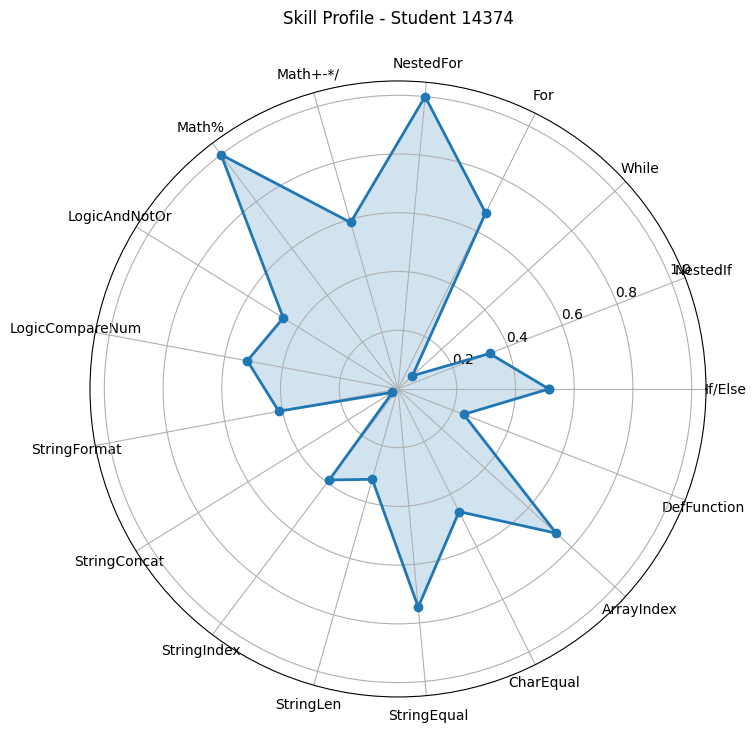

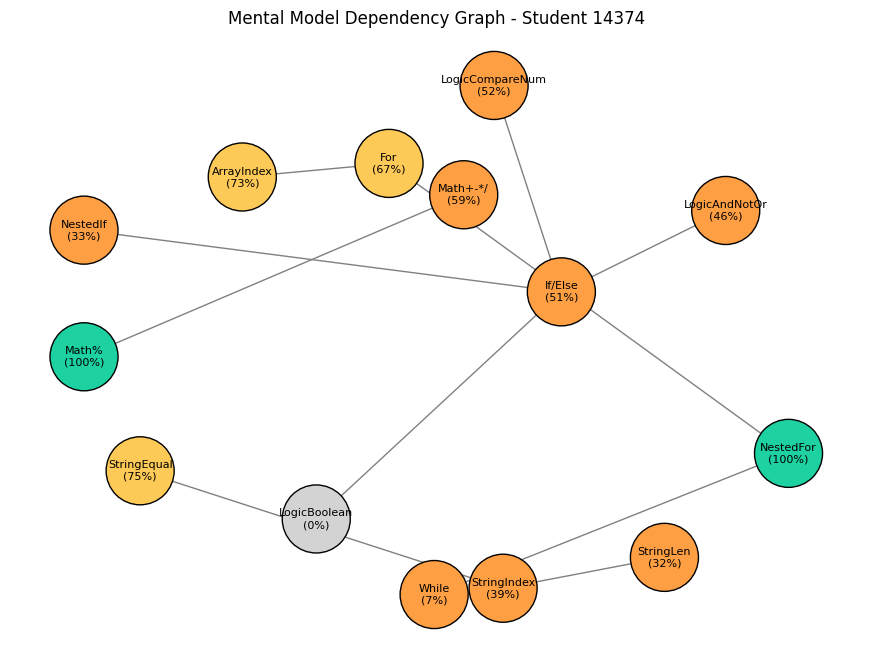

In [19]:
# 4) Visualize Mental Model (Radar + Dependency Graph)
def plot_radar(student_profile, all_skills, title):
    active_skills = [s for s in all_skills if student_profile.get(s, 0) > 0]
    if not active_skills:
        print("No active skills to plot.")
        return

    labels = np.array(active_skills)
    values = np.array([student_profile.get(s, 0) for s in active_skills])
    values = np.concatenate((values, [values[0]]))
    angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)
    angles = np.concatenate((angles, [angles[0]]))

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    ax.plot(angles, values, 'o-', linewidth=2)
    ax.fill(angles, values, alpha=0.2)
    ax.set_thetagrids(angles[:-1] * 180/np.pi, labels)
    ax.set_title(title, y=1.08)
    ax.grid(True)
    plt.show()

def plot_weak_dependency_graph(graph, weak_skill_pairs):
    weak_set = {s for s, _ in weak_skill_pairs}
    if graph.number_of_nodes() == 0:
        print("No dependency graph available.")
        return

    node_colors = []
    labels = {}
    for node in graph.nodes():
        score = student_profile.get(node, 0)
        labels[node] = f"{node}\n({score*100:.0f}%)"
        if node in weak_set:
            node_colors.append("#ff9f43")
        elif score >= 0.8:
            node_colors.append("#1dd1a1")
        elif score > 0:
            node_colors.append("#feca57")
        else:
            node_colors.append("#d3d3d3")

    pos = nx.spring_layout(graph, seed=RANDOM_SEED, k=1.4)
    plt.figure(figsize=(11, 8))
    nx.draw_networkx_nodes(graph, pos, node_color=node_colors, node_size=2400, edgecolors='black')
    nx.draw_networkx_edges(graph, pos, arrows=True, arrowstyle='->', arrowsize=18, edge_color='gray')
    nx.draw_networkx_labels(graph, pos, labels=labels, font_size=8)
    plt.title(f"Mental Model Dependency Graph - Student {TARGET_STUDENT_ID}")
    plt.axis('off')
    plt.show()

plot_radar(student_profile, all_skills, f"Skill Profile - Student {TARGET_STUDENT_ID}")
plot_weak_dependency_graph(G, weak_skills[:12])

In [20]:
# 5) Build Mental-Model Context + Context-Enriched Prompt
mental_model = build_mental_model_payload(
    student_id=TARGET_STUDENT_ID,
    profile=student_profile,
    weak_skill_pairs=weak_skills,
    graph=G,
)
print(json.dumps(mental_model, indent=2)[:3000])

context_enriched_prompt_text = build_context_enriched_prompt(
    student_problem_ids=list(student_data["ProblemID"].unique()),
    mental_model=mental_model,
)
print("Context-enriched prompt prepared.")

{
  "student_id": "14374",
  "top_weak_skills": [
    {
      "skill": "StringConcat",
      "mastery": 0.022
    },
    {
      "skill": "While",
      "mastery": 0.067
    },
    {
      "skill": "DefFunction",
      "mastery": 0.24
    },
    {
      "skill": "StringLen",
      "mastery": 0.32
    },
    {
      "skill": "NestedIf",
      "mastery": 0.334
    },
    {
      "skill": "StringIndex",
      "mastery": 0.388
    },
    {
      "skill": "StringFormat",
      "mastery": 0.413
    },
    {
      "skill": "LogicAndNotOr",
      "mastery": 0.459
    },
    {
      "skill": "CharEqual",
      "mastery": 0.467
    },
    {
      "skill": "If/Else",
      "mastery": 0.514
    }
  ],
  "top_strong_skills": [
    {
      "skill": "NestedFor",
      "mastery": 1.0
    },
    {
      "skill": "Math%",
      "mastery": 1.0
    },
    {
      "skill": "StringEqual",
      "mastery": 0.746
    },
    {
      "skill": "ArrayIndex",
      "mastery": 0.729
    },
    {
      "skill": "For

In [21]:
# 7) Create Held-Out Evaluation Set
EVAL_SIZE = min(6, len(student_data))
eval_pool = student_data.sample(n=EVAL_SIZE, random_state=RANDOM_SEED).copy()

print(f"Evaluation submissions: {len(eval_pool)}")
display(eval_pool[["ProblemID", "Score"]])

Evaluation submissions: 6


,ProblemID,Score
31,232,0.000000
15,41,1.000000
26,67,0.550000
17,44,1.000000
8,25,0.761905
9,28,0.000000


In [22]:
# 8) Run Evaluation with Context-Enriched Prompt
context_eval_df = run_context_enriched_eval(
    eval_df=eval_pool,
    student_id=TARGET_STUDENT_ID,
    weak_skills=weak_skills,
    prompt_text=context_enriched_prompt_text,
    client=client,
    model_id=MODEL_ID,
)

display(context_eval_df[[
    "ProblemID",
    "Score",
    "ContextEnriched_TimeSec",
    "ContextEnriched_WeakSkillOverlap",
]])

context_eval_csv = f"mental_model_context_enriched_student_{TARGET_STUDENT_ID}.csv"
save_results(context_eval_df, context_eval_csv)
print(f"Saved: {context_eval_csv}")

,ProblemID,Score,ContextEnriched_TimeSec,ContextEnriched_WeakSkillOverlap
0,232,0.000000,10.032,0
1,41,1.000000,4.791,0
2,67,0.550000,11.635,0
3,44,1.000000,10.519,0
4,25,0.761905,8.478,0
5,28,0.000000,13.770,0


Saved: mental_model_context_enriched_student_14374.csv


In [ ]:
# 9) Summary of Context-Enriched Prompt Results
if 'context_eval_df' not in locals() or context_eval_df.empty:
    raise ValueError("Run the context-enriched evaluation first.")

summary_df = summarize_context_eval(context_eval_df, TARGET_STUDENT_ID)
display(summary_df)

summary_csv = f"mental_model_context_enriched_summary_student_{TARGET_STUDENT_ID}.csv"
save_results(summary_df, summary_csv)
print(f"Saved: {summary_csv}")